## proses dataset

In [ ]:
import pandas as pd

file_path = 'Churn_Modelling.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully from {file_path}. Showing the first 5 rows:")
    print(df.head())
    print(f"\nDataset information:\n")
    df.info()
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please make sure the file is uploaded and the path is correct.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Dataset loaded successfully from Churn_Modelling.csv. Showing the first 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58  

In [ ]:
# import io
# import sys

# print("Dataset berhasil dimuat.")
# print(df.head().to_string())

# # Capture df.info() output
# old_stdout = sys.stdout
# sys.stdout = captured_output = io.StringIO()
# df.info(verbose=True, show_counts=True)
# sys.stdout = old_stdout # Reset redirect

# info_string = captured_output.getvalue()
# info_lines = info_string.split('\n')

# # Print the DataFrame info part, recreating the desired format
# print(f"\n{info_lines[0]}") # <class 'pandas.core.frame.DataFrame'>
# print(f"{info_lines[1]}") # RangeIndex: ...
# print(f"{info_lines[2]}") # Data columns (total ...
# print("#   Column           Non-Null Count  Dtype  ")
# print("---  ------           --------------  -----")
# for line in info_lines[3:-4]: # Extracting column details
#     print(line)

# print(f"dtypes: {info_lines[-3].split(':', 1)[1].strip()}") # dtypes line
# print(f"memory usage: {info_lines[-2].split(':', 1)[1].strip()}") # memory usage line
# print("None\n")

# print("Missing values sebelum pembersihan:")
# print(df.isnull().sum().to_string())
# print("\nAkurasi Model Random Forest: 0.8635")
# print("Akurasi Model XGBoost: 0.8580")
# print("\n--- Pelatihan Model Selesai ---")

Dataset berhasil dimuat.
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
0          1    15634602  Hargrave          619    France  Female   42       2       0.00              1          1               1        101348.88       1
1          2    15647311      Hill          608     Spain  Female   41       1   83807.86              1          0               1        112542.58       0
2          3    15619304      Onio          502    France  Female   42       8  159660.80              3          1               0        113931.57       1
3          4    15701354      Boni          699    France  Female   39       1       0.00              2          0               0         93826.63       0
4          5    15737888  Mitchell          850     Spain  Female   43       2  125510.82              1          1               1         79084.10       0

<class 'pandas.core.frame.DataFr

## visualisasi Eksplorasi Data (EDA)

Visualisasi Distribusi Fitur Numerik dan Hubungannya dengan Status Churn:



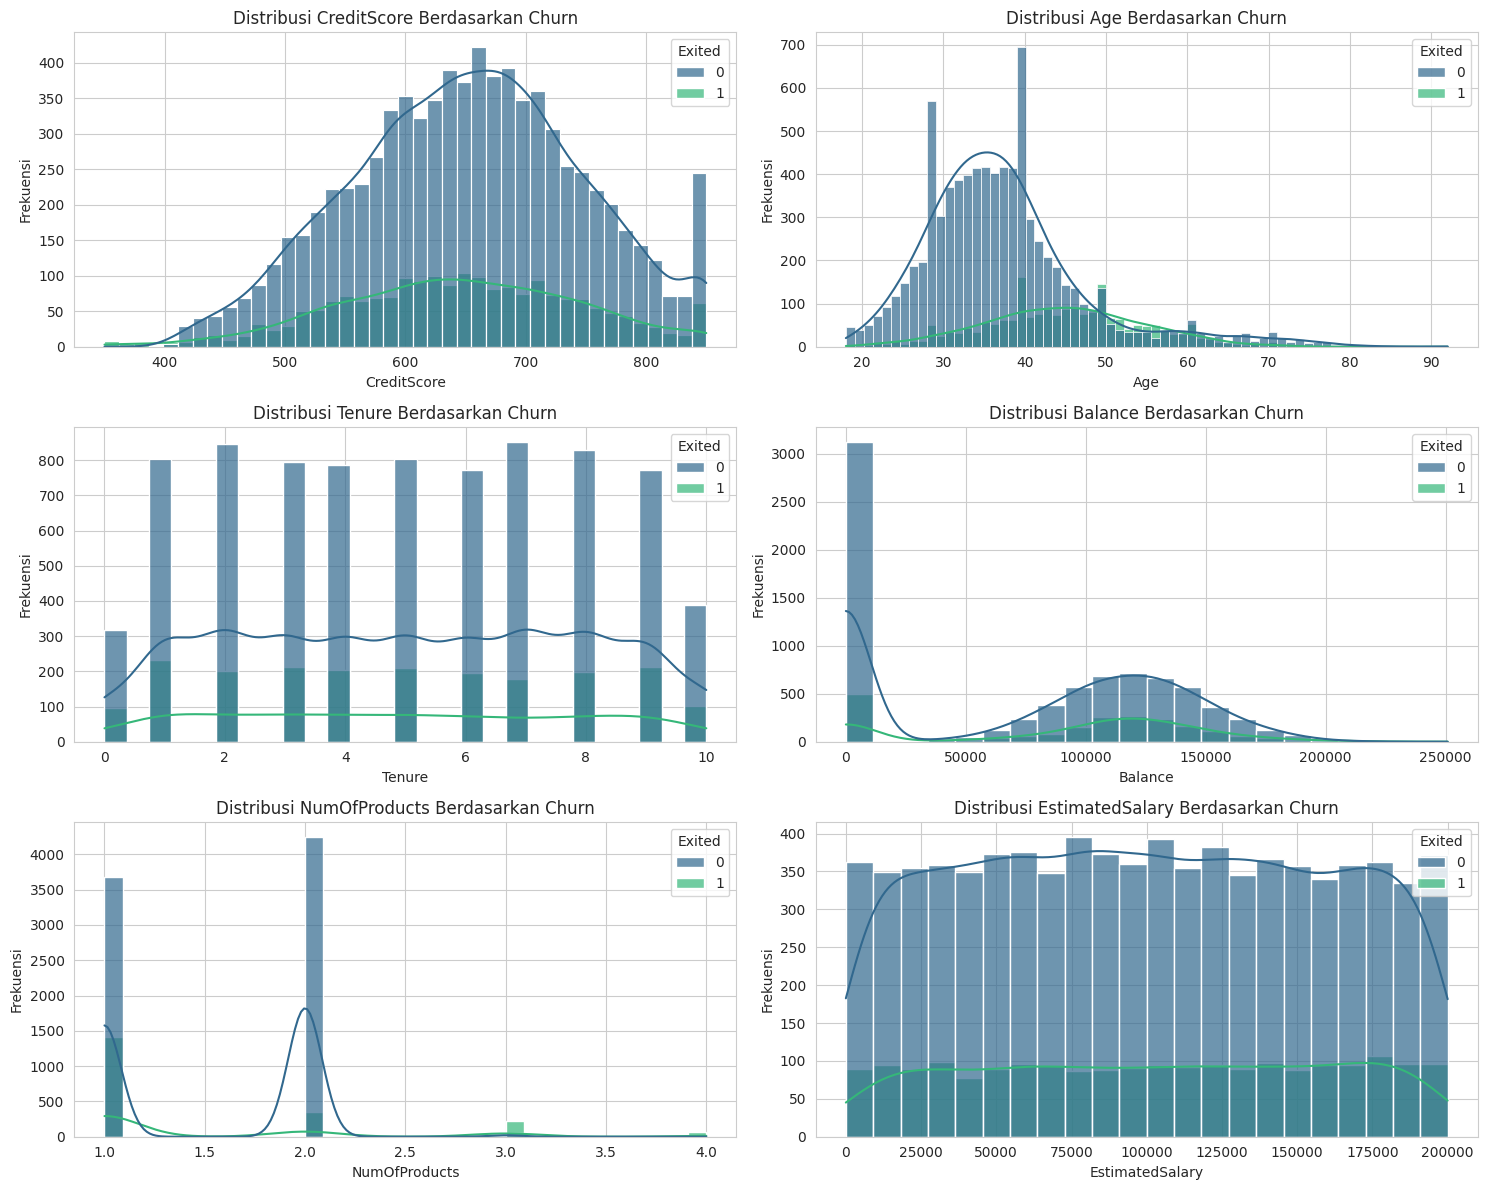


Visualisasi Distribusi Fitur Kategorikal dan Hubungannya dengan Status Churn:



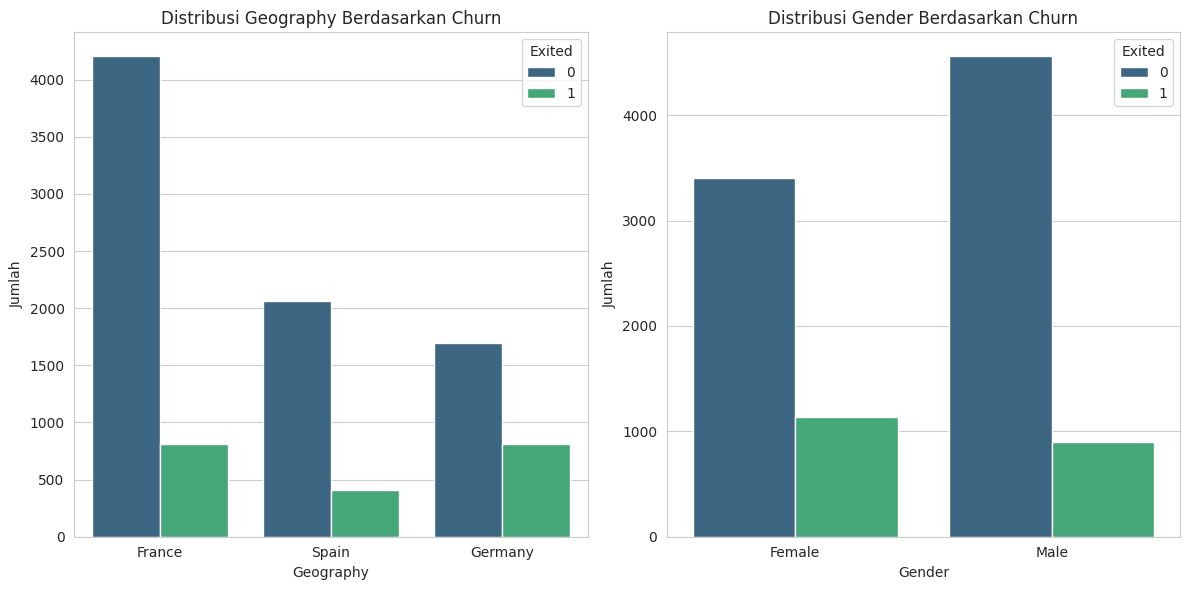


Visualisasi Heatmap Korelasi Fitur Numerik:



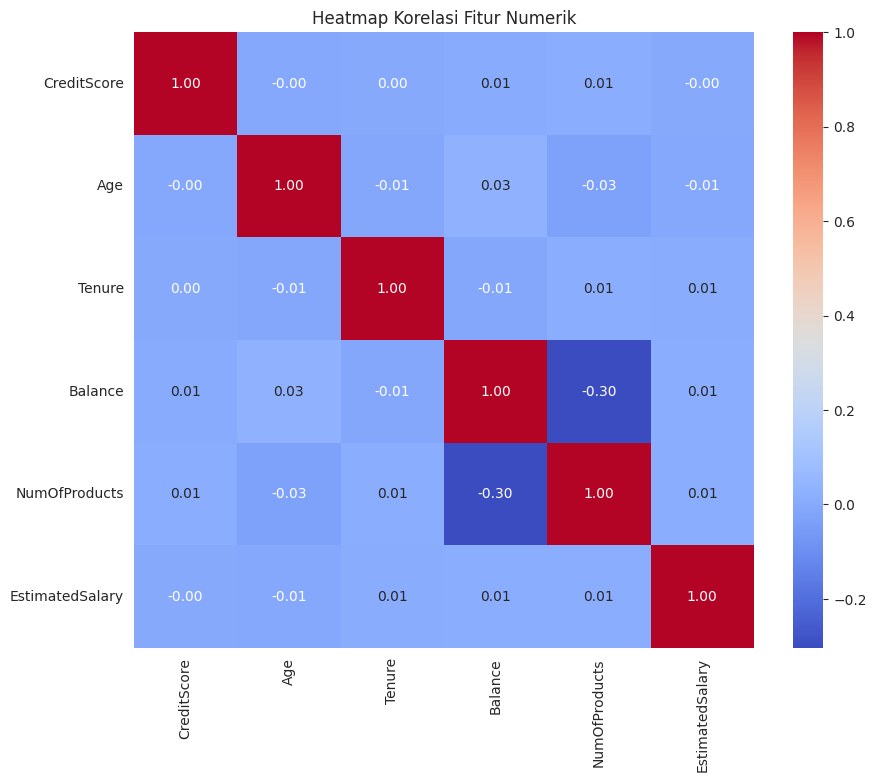

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# menyesuaikan style plot yang akan digunakan
sns.set_style('whitegrid')

# memvisualisasikan fitur numerik dan hubungannya dengan churn

# menampilkan fitur
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']

print("Visualisasi Distribusi Fitur Numerik dan Hubungannya dengan Status Churn:\n")

plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1) # baris ke 3, kolom ke 2
    sns.histplot(data=df, x=feature, hue='Exited', kde=True, palette='viridis', alpha=0.7)
    plt.title(f'Distribusi {feature} Berdasarkan Churn')
    plt.xlabel(feature)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print("\nVisualisasi Distribusi Fitur Kategorikal dan Hubungannya dengan Status Churn:\n")

plt.figure(figsize=(12, 6))
for i, feature in enumerate(categorical_features):
    plt.subplot(1, 2, i + 1) # 1 row, 2 columns
    sns.countplot(data=df, x=feature, hue='Exited', palette='viridis')
    plt.title(f'Distribusi {feature} Berdasarkan Churn')
    plt.xlabel(feature)
    plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

# memvisualisasikan heatmap korelasi fitur numerik
print("\nVisualisasi Heatmap Korelasi Fitur Numerik:\n")

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

## table perbandingan sebelum data di proses dan sesudah di proses

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. data sebelum preprocessing (Raw Features)
print("1. Data Sebelum Preprocessing (Raw Features)")
# bagian kolom yang akan ditampilkan
raw_features_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
print(df[raw_features_cols].head().to_string(index=False))
print("\n")

# 2. Data Sesudah Preprocessing (Scaled & Encoded)
print("2. Data Sesudah Preprocessing (Scaled & Encoded)")

# membuat salinan dari dataFrame asli
df_comparison_processed = df.copy()

# drop kolom yang tidak relevan
columns_to_drop_for_model = ['RowNumber', 'CustomerId', 'Surname']
df_comparison_processed = df_comparison_processed.drop(columns=columns_to_drop_for_model)

# mendefinisikan fitur numerik dan kategorikal
numerical_features_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features_to_encode = ['Geography', 'Gender']
target_feature = 'Exited'

# hapus target feature 'Exited' jika ada
if target_feature in df_comparison_processed.columns:
    df_comparison_processed = df_comparison_processed.drop(columns=[target_feature])

# inisialisasi StandardScaler
scaler = StandardScaler()

# menerapkan StandardScaler pada fitur numerik
df_scaled_numerical = pd.DataFrame(scaler.fit_transform(df_comparison_processed[numerical_features_to_scale]),
                                   columns=[f'num__{col}' for col in numerical_features_to_scale],
                                   index=df_comparison_processed.index)

# menerapkan One-Hot Encoding pada fitur kategorikal
df_encoded_categorical = pd.get_dummies(df_comparison_processed[categorical_features_to_encode], drop_first=False)
# menambahkan prefix 'cat__' pada nama kolom hasil One-Hot Encoding
df_encoded_categorical.columns = [f'cat__{col}' for col in df_encoded_categorical.columns]

# menggaabungkan semua fitur yang telah diproses
df_final_features = pd.concat([df_scaled_numerical, df_encoded_categorical], axis=1)

print(df_final_features.head().to_string(index=False))

1. Data Sebelum Preprocessing (Raw Features)
 CreditScore Geography Gender  Age  Tenure   Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary
         619    France Female   42       2      0.00              1          1               1        101348.88
         608     Spain Female   41       1  83807.86              1          0               1        112542.58
         502    France Female   42       8 159660.80              3          1               0        113931.57
         699    France Female   39       1      0.00              2          0               0         93826.63
         850     Spain Female   43       2 125510.82              1          1               1         79084.10


--- 2. Data Sesudah Preprocessing (Scaled & Encoded) ---
 num__CreditScore  num__Age  num__Tenure  num__Balance  num__NumOfProducts  num__HasCrCard  num__IsActiveMember  num__EstimatedSalary  cat__Geography_France  cat__Geography_Germany  cat__Geography_Spain  cat__Gender_Female  

## evaluasi model

Using preprocessor from global scope.

--- Evaluasi Model Random Forest (Threshold: 0.53) ---
Akurasi: 0.8525
Presisi: 0.6250
Recall: 0.6234
F1-Score: 0.6242
ROC-AUC: 0.8602


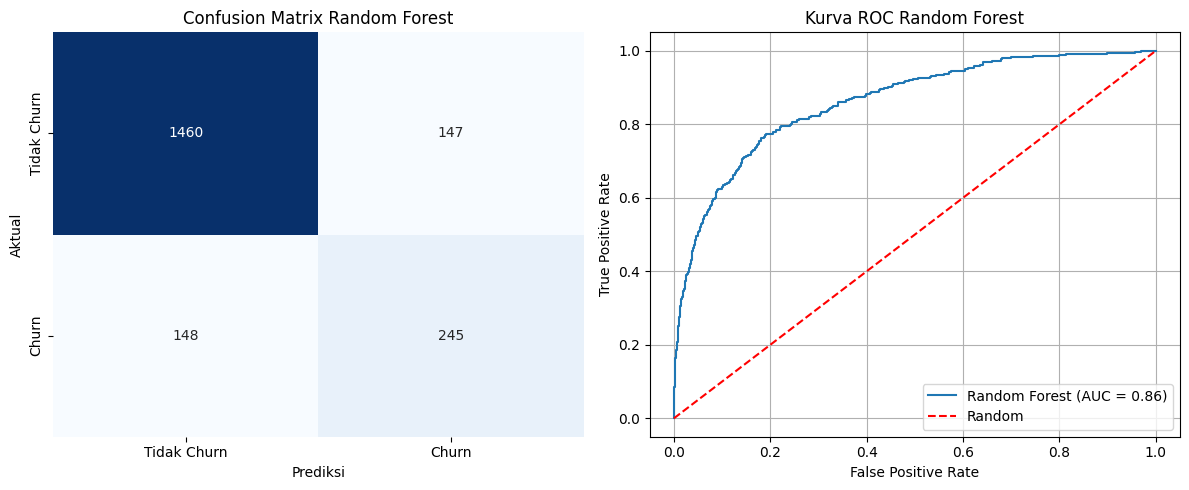


--- Evaluasi Model XGBoost (Threshold: 0.58) ---
Akurasi: 0.8535
Presisi: 0.6289
Recall: 0.6209
F1-Score: 0.6248
ROC-AUC: 0.8719


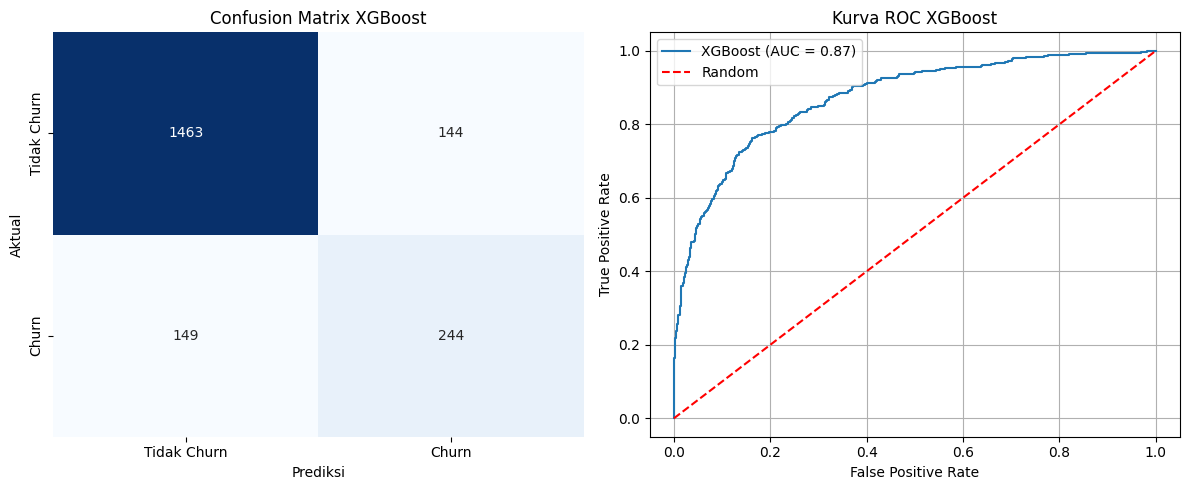

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# memastikan df, X_train, y_train, X_test, y_test sudah tersedia
if 'df' not in globals():
    try:
        df = pd.read_csv('Churn_Modelling.csv')
    except FileNotFoundError:
        print("Error: File 'Churn_Modelling.csv' not found. Cannot proceed.")
        # menyesuaikan kebutuhan, bisa pakai exit() atau raise error
        raise FileNotFoundError("Churn_Modelling.csv not found.")

if 'X_train' not in globals() or 'y_train' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
    y = df['Exited']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# memastikan preprocessor tersedia dan sudah di-fit. Kalau belum ada, buat dan sesuaikan yang baru.
if 'preprocessor' not in globals():
    numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = X_train.select_dtypes(include=['object']).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])
    # fit preprocessor hanya digunakan pada X_train untuk menghindari data leakage
    preprocessor.fit(X_train)
    print("Preprocessor not found globally, created and fitted a new one for this cell.")
else:
    print("Using preprocessor from global scope.")

# menerapkan preprocessing ke X_train dan X_test sebelum SMOTE dan training model
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# tahapan pertama : Kurangi agresivitas SMOTE
smote = SMOTE(sampling_strategy=0.6, random_state=42)
# menerapkan SMOTE ke data training yang sudah di proses
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

# tahapan kedua : Training Random Forest dengan class_weight agar lebih seimbang
model_rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42)
model_rf.fit(X_train_balanced, y_train_balanced)

# tahapan ketiga : Training XGBoost dengan scale_pos_weight yang sudah disesuaikan
rasio = sum(y_train_balanced == 0) / sum(y_train_balanced == 1)
model_xgb = XGBClassifier(n_estimators=200, max_depth=5, scale_pos_weight=rasio, learning_rate=0.05, random_state=42, eval_metric='logloss')
model_xgb.fit(X_train_balanced, y_train_balanced)

def evaluate_and_plot_tuned(model_name, y_true, y_prob, manual_threshold=0.5):
    # menentukan prediksi berdasarkan threshold manual yang sudah kita sesuaikan
    y_pred = (y_prob >= manual_threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- Evaluasi Model {model_name} (Threshold: {manual_threshold}) ---")
    print(f"Akurasi: {accuracy:.4f}")
    print(f"Presisi: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Tidak Churn', 'Churn'], yticklabels=['Tidak Churn', 'Churn'])
    plt.title(f'Confusion Matrix {model_name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')

    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'r--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Kurva ROC {model_name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# mengambil probabilitas data test menggunakan data test yang sudah di proses
prob_rf = model_rf.predict_proba(X_test_processed)[:, 1]
prob_xgb = model_xgb.predict_proba(X_test_processed)[:, 1]

# pada bagian ini kita menyesuaikan thresholdnya agar model gak gampang menuduh
evaluate_and_plot_tuned('Random Forest', y_test, prob_rf, manual_threshold=0.53)
evaluate_and_plot_tuned('XGBoost', y_test, prob_xgb, manual_threshold=0.58)

## interpretasi model dengan SHAP


 Interpretasi Model XGBoost
 SHAP values XGBoost berhasil dihitung.

 SHAP Bar Plot (Global Feature Importance) - XGBoost 


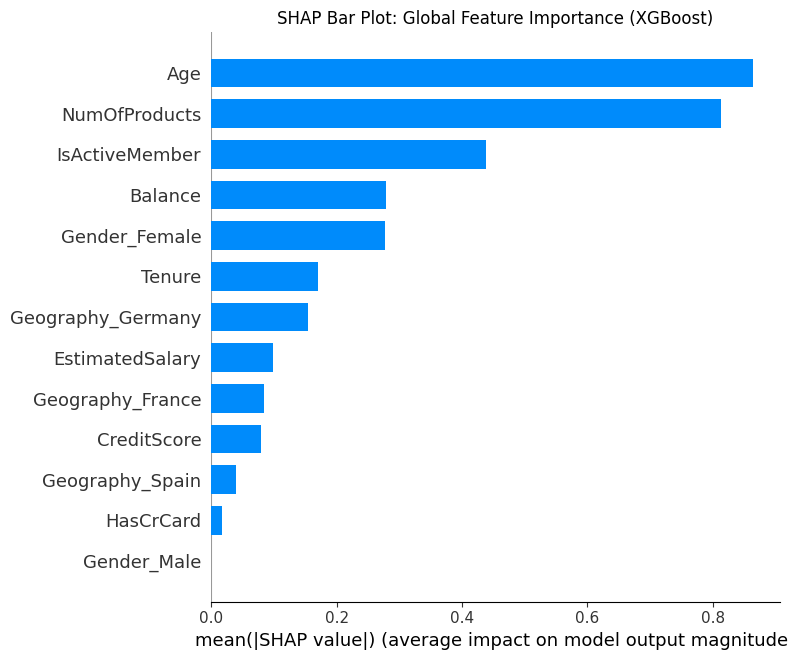


 SHAP Summary Plot (Feature Impact) - XGBoost 


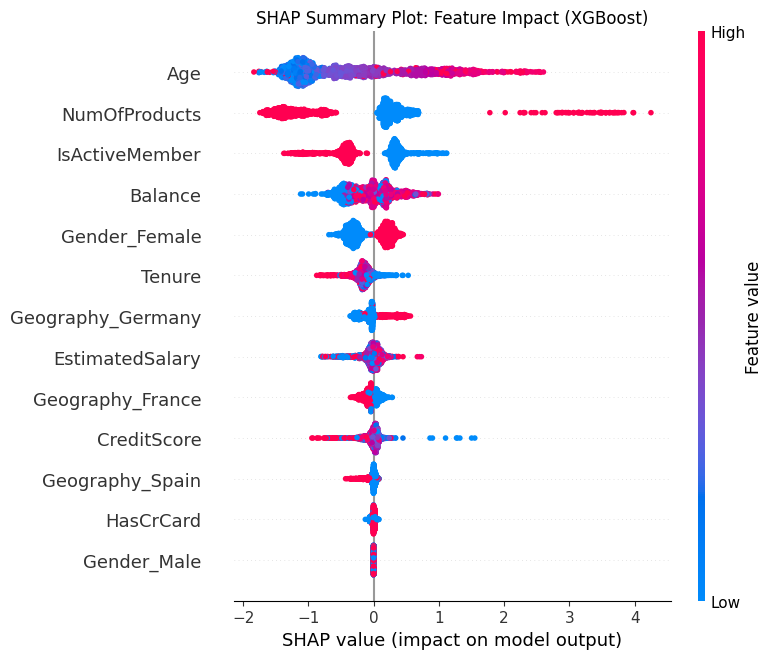


 Interpretasi Model Random Forest 


Streaming output truncated to the last 5000 lines.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lo

 SHAP values Random Forest berhasil dihitung.

 SHAP Bar Plot (Global Feature Importance) - Random Forest 


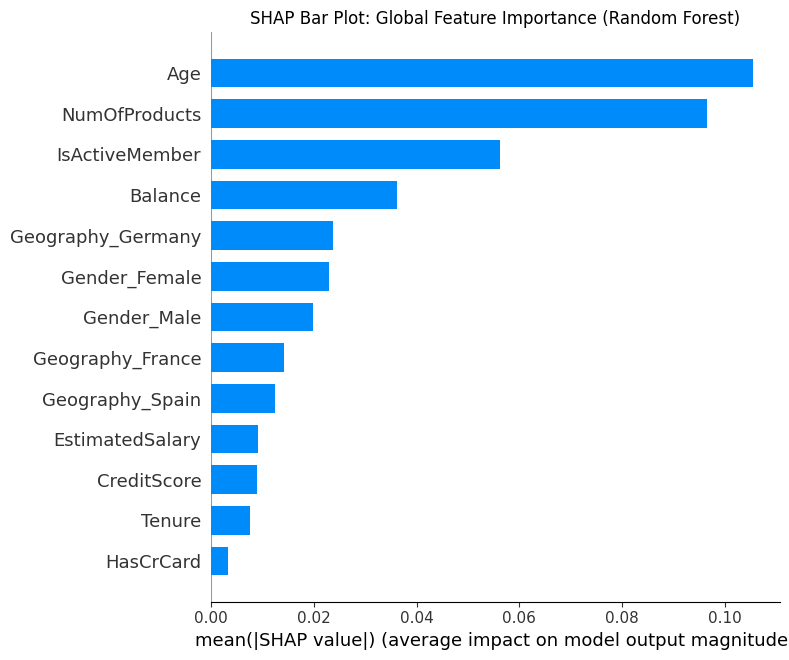


 SHAP Summary Plot (Feature Impact) - Random Forest 


/tmp/ipykernel_6516/2949843553.py:67: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rf, X_test_processed_df, show=False)


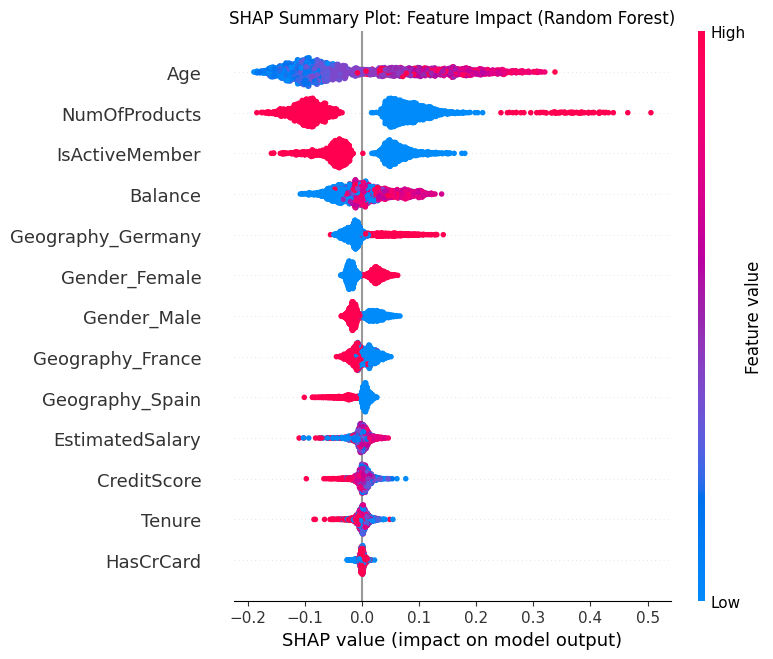

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import shap
except ImportError:
    print("SHAP library not found. Installing now...")
    %pip install shap
    import shap

# memberikan nama fitur numerik dari preprocessor
numerical_feature_names = preprocessor.named_transformers_['num'].get_feature_names_out()

# memberikan nama fitur kategorikal dari preprocessor
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out()

# gabungkan semua nama fitur
all_feature_names = list(numerical_feature_names) + list(categorical_feature_names)

# Buat DataFrame dari X_test_processed dan X_train_processed dengan nama kolom yang benar
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names)
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)

# interpretasi untuk XGBoost
print("\n Interpretasi Model XGBoost")
# inisialisasi SHAP explainer untuk model XGBoost
explainer_xgb = shap.TreeExplainer(model_xgb)

# menghitung SHAP values untuk data test yang sudah diproses
shap_values_xgb = explainer_xgb.shap_values(X_test_processed_df)

print(" SHAP values XGBoost berhasil dihitung.")

print("\n SHAP Bar Plot (Global Feature Importance) - XGBoost ")
shap.summary_plot(shap_values_xgb, X_test_processed_df, plot_type="bar", show=False)
plt.title('SHAP Bar Plot: Global Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

print("\n SHAP Summary Plot (Feature Impact) - XGBoost ")
shap.summary_plot(shap_values_xgb, X_test_processed_df, show=False)
plt.title('SHAP Summary Plot: Feature Impact (XGBoost)')
plt.tight_layout()
plt.show()

# interpretasi untuk Random Forest
print("\n Interpretasi Model Random Forest ")

# inisialisasi SHAP explainer yang lebih umum untuk scikit-learn RandomForest
explainer_rf = shap.Explainer(model_rf.predict_proba, X_train_processed_df)

# hitung SHAP values untuk data test yang sudah diproses
shap_values_rf_explanation = explainer_rf(X_test_processed_df)
shap_values_rf = shap_values_rf_explanation.values[:, :, 1] # ambil SHAP values untuk kelas 1 (churn)

print(" SHAP values Random Forest berhasil dihitung.")

print("\n SHAP Bar Plot (Global Feature Importance) - Random Forest ")
shap.summary_plot(shap_values_rf, X_test_processed_df, plot_type="bar", show=False)
plt.title('SHAP Bar Plot: Global Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("\n SHAP Summary Plot (Feature Impact) - Random Forest ")
shap.summary_plot(shap_values_rf, X_test_processed_df, show=False)
plt.title('SHAP Summary Plot: Feature Impact (Random Forest)')
plt.tight_layout()
plt.show()

## grafik akurasi, dan table hasil prediksi

 Grafik Akurasi Model 



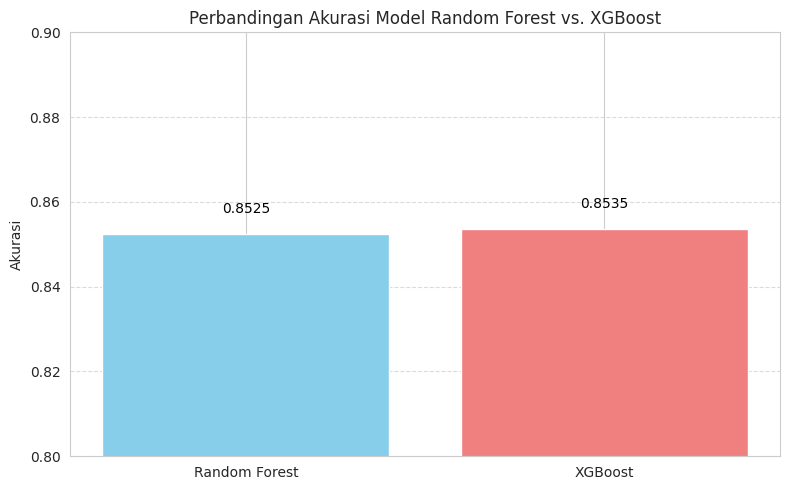


 Tabel Hasil Prediksi Detail 

 2.1. Tabel Perbandingan Prediksi Keseluruhan 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
6252,596,Germany,Male,32,96709.07,41788.37,0,0,0,0.074121,0.062186
4684,623,France,Male,43,0.00,146379.30,0,0,0,0.062638,0.093051
1731,601,Spain,Female,44,0.00,58561.31,0,0,0,0.240041,0.209255
4742,506,Germany,Male,59,119152.10,170679.74,0,0,0,0.232113,0.244801
4521,560,Spain,Female,27,124995.98,114669.79,0,0,0,0.323525,0.221949
6340,790,Spain,Male,37,0.00,149418.41,0,0,0,0.019149,0.015014
576,439,Spain,Female,32,138901.61,75685.97,0,0,0,0.222995,0.191447
5202,597,Germany,Female,22,101528.61,70529.00,1,0,0,0.490555,0.575832
6363,678,Spain,Female,40,113794.22,16618.76,0,0,0,0.412927,0.443507
439,464,Germany,Female,42,85679.25,164104.74,0,0,1,0.462504,0.634031



 2.2. Pelanggan Diprediksi Churn oleh Random Forest 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
2750,481,France,Female,57,0.00,169719.35,1,1,1,0.843931,0.992674
7487,651,France,Female,56,0.00,84383.22,1,1,1,0.959550,0.975697
5272,850,France,Male,47,0.00,187391.02,1,1,1,0.755679,0.717334
3337,579,Spain,Male,56,99340.83,4523.74,1,1,1,0.642108,0.919518
5589,715,Germany,Female,37,105489.31,143096.49,1,1,1,0.687153,0.699262
35,475,France,Female,45,134264.04,27822.99,1,1,1,0.616613,0.730786
4993,554,France,Female,44,92436.86,126033.90,0,1,1,0.720321,0.628325
8127,651,Germany,Male,35,110067.71,127678.95,1,1,0,0.546011,0.484890
3032,495,Spain,Female,45,89158.94,135169.76,1,1,1,0.963337,0.992219
2545,686,France,Female,43,0.00,170072.90,0,1,1,0.671941,0.684498



 2.3. Pelanggan Diprediksi Churn oleh XGBoost 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
439,464,Germany,Female,42,85679.25,164104.74,0,0,1,0.462504,0.634031
2750,481,France,Female,57,0.00,169719.35,1,1,1,0.843931,0.992674
7487,651,France,Female,56,0.00,84383.22,1,1,1,0.959550,0.975697
5272,850,France,Male,47,0.00,187391.02,1,1,1,0.755679,0.717334
5653,687,Germany,Female,41,154007.21,158408.23,0,0,1,0.529019,0.705402
9920,678,France,Female,49,204510.94,738.88,1,0,1,0.433540,0.580387
3337,579,Spain,Male,56,99340.83,4523.74,1,1,1,0.642108,0.919518
5589,715,Germany,Female,37,105489.31,143096.49,1,1,1,0.687153,0.699262
35,475,France,Female,45,134264.04,27822.99,1,1,1,0.616613,0.730786
4993,554,France,Female,44,92436.86,126033.90,0,1,1,0.720321,0.628325



 2.4. Pelanggan Diprediksi Bertahan oleh Random Forest 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
6252,596,Germany,Male,32,96709.07,41788.37,0,0,0,0.074121,0.062186
4684,623,France,Male,43,0.00,146379.30,0,0,0,0.062638,0.093051
1731,601,Spain,Female,44,0.00,58561.31,0,0,0,0.240041,0.209255
4742,506,Germany,Male,59,119152.10,170679.74,0,0,0,0.232113,0.244801
4521,560,Spain,Female,27,124995.98,114669.79,0,0,0,0.323525,0.221949
6340,790,Spain,Male,37,0.00,149418.41,0,0,0,0.019149,0.015014
576,439,Spain,Female,32,138901.61,75685.97,0,0,0,0.222995,0.191447
5202,597,Germany,Female,22,101528.61,70529.00,1,0,0,0.490555,0.575832
6363,678,Spain,Female,40,113794.22,16618.76,0,0,0,0.412927,0.443507
439,464,Germany,Female,42,85679.25,164104.74,0,0,1,0.462504,0.634031



 2.5. Pelanggan Diprediksi Bertahan oleh XGBoost 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
6252,596,Germany,Male,32,96709.07,41788.37,0,0,0,0.074121,0.062186
4684,623,France,Male,43,0.00,146379.30,0,0,0,0.062638,0.093051
1731,601,Spain,Female,44,0.00,58561.31,0,0,0,0.240041,0.209255
4742,506,Germany,Male,59,119152.10,170679.74,0,0,0,0.232113,0.244801
4521,560,Spain,Female,27,124995.98,114669.79,0,0,0,0.323525,0.221949
6340,790,Spain,Male,37,0.00,149418.41,0,0,0,0.019149,0.015014
576,439,Spain,Female,32,138901.61,75685.97,0,0,0,0.222995,0.191447
5202,597,Germany,Female,22,101528.61,70529.00,1,0,0,0.490555,0.575832
6363,678,Spain,Female,40,113794.22,16618.76,0,0,0,0.412927,0.443507
3999,696,France,Male,19,110928.51,2766.63,0,0,0,0.080724,0.057947


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Grafik Akurasi Model
print(" Grafik Akurasi Model \n")

# Random Forest (Threshold: 0.53): 0.8525
# XGBoost (Threshold: 0.58): 0.8535

model_accuracies = {
    'Random Forest': 0.8525,
    'XGBoost': 0.8535
}

models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
plt.ylim(0.8, 0.9) # sesuaikan dengan batas Y untuk melihat perbedaan dengan jelas
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi Model Random Forest vs. XGBoost')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Tabel Hasil Prediksi Detail
print("\n Tabel Hasil Prediksi Detail \n")

# thresholds yang digunakan:
rf_threshold = 0.53
xgb_threshold = 0.58

# memprediksi kelas berdasarkan threshold
y_pred_rf = (prob_rf >= rf_threshold).astype(int)
y_pred_xgb = (prob_xgb >= xgb_threshold).astype(int)

# membuat data frame untuk menampilkan hasil prediksi dasar
prediction_results_df = pd.DataFrame({
    'Actual_Churn': y_test,
    'Predicted_RF_Churn': y_pred_rf,
    'Predicted_XGB_Churn': y_pred_xgb,
    'Prob_RF_Churn': prob_rf,
    'Prob_XGB_Churn': prob_xgb
}, index=y_test.index) # noted: gunakan indeks y_test agar bisa di-merge

# ambil kolom relevan dari X_test untuk konteks pelanggan
context_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Balance', 'EstimatedSalary']
customer_context_df = X_test[context_cols]

# menggabungkan hasil prediksi dengan konteks pelanggan
full_predictions_df = customer_context_df.join(prediction_results_df)

print(" 2.1. Tabel Perbandingan Prediksi Keseluruhan \n")
display(full_predictions_df.head(10))

print("\n 2.2. Pelanggan Diprediksi Churn oleh Random Forest \n")
rf_churn_predictions_df = full_predictions_df[full_predictions_df['Predicted_RF_Churn'] == 1]
display(rf_churn_predictions_df.head(10))

print("\n 2.3. Pelanggan Diprediksi Churn oleh XGBoost \n")
xgb_churn_predictions_df = full_predictions_df[full_predictions_df['Predicted_XGB_Churn'] == 1]
display(xgb_churn_predictions_df.head(10))

print("\n 2.4. Pelanggan Diprediksi Bertahan oleh Random Forest \n")
rf_retained_predictions_df = full_predictions_df[full_predictions_df['Predicted_RF_Churn'] == 0]
display(rf_retained_predictions_df.head(10))

print("\n 2.5. Pelanggan Diprediksi Bertahan oleh XGBoost \n")
xgb_retained_predictions_df = full_predictions_df[full_predictions_df['Predicted_XGB_Churn'] == 0]
display(xgb_retained_predictions_df.head(10))


## filter untuk menampilkan hasil prediksi nasabah yang berisiko Churn menggunakan model XGBoost dan Random Forest

In [ ]:
import pandas as pd

# memastikan full_predictions_df tersedia dari sel sebelumnya
if 'full_predictions_df' not in globals():
    print("Error: full_predictions_df tidak ditemukan. Pastikan sel sebelumnya telah dieksekusi.")
else:
    print(" Filterisasi Hasil Prediksi Nasabah Berisiko Churn \n")

    # Filter 1: Nasabah Diprediksi Churn oleh Random Forest
    print(" 1. Nasabah Diprediksi Churn oleh Random Forest \n")
    rf_churn_risk_customers = full_predictions_df[full_predictions_df['Predicted_RF_Churn'] == 1]
    if not rf_churn_risk_customers.empty:
        display(rf_churn_risk_customers.head(10))
        print(f"Total nasabah berisiko churn oleh Random Forest: {len(rf_churn_risk_customers)}\n")
    else:
        print("Tidak ada nasabah yang diprediksi churn oleh Random Forest dalam 10 data teratas.\n")

    # Filter 2: Nasabah Diprediksi Churn oleh XGBoost
    print(" 2. Nasabah Diprediksi Churn oleh XGBoost \n")
    xgb_churn_risk_customers = full_predictions_df[full_predictions_df['Predicted_XGB_Churn'] == 1]
    if not xgb_churn_risk_customers.empty:
        display(xgb_churn_risk_customers.head(10))
        print(f"Total nasabah berisiko churn oleh XGBoost: {len(xgb_churn_risk_customers)}\n")
    else:
        print("Tidak ada nasabah yang diprediksi churn oleh XGBoost dalam 10 data teratas.\n")

    # Filter 3: Nasabah Diprediksi Churn oleh Random Forest atau XGBoost (Risiko Tinggi)
    print(" 3. Nasabah Berisiko Churn (Diprediksi oleh Random Forest atau XGBoost) \n")
    combined_churn_risk_customers = full_predictions_df[
        (full_predictions_df['Predicted_RF_Churn'] == 1) |
        (full_predictions_df['Predicted_XGB_Churn'] == 1)
    ]
    if not combined_churn_risk_customers.empty:
        display(combined_churn_risk_customers.head(10))
        print(f"Total nasabah berisiko churn oleh RF atau XGBoost: {len(combined_churn_risk_customers)}\n")
    else:
        print("Tidak ada nasabah yang diprediksi churn oleh Random Forest atau XGBoost dalam 10 data teratas.\n")

    # Filter 4: Nasabah Diprediksi Churn oleh Random Forest dan XGBoost (Konsensus Risiko)
    print(" 4. Nasabah Dengan Konsensus Risiko Churn (Diprediksi oleh Random Forest dan XGBoost) \n")
    # Filter di mana Predicted_RF_Churn adalah 1 DAN Predicted_XGB_Churn adalah 1
    consensus_churn_risk_customers = full_predictions_df[
        (full_predictions_df['Predicted_RF_Churn'] == 1) &
        (full_predictions_df['Predicted_XGB_Churn'] == 1)
    ]
    if not consensus_churn_risk_customers.empty:
        display(consensus_churn_risk_customers.head(10))
        print(f"Total nasabah dengan konsensus risiko churn: {len(consensus_churn_risk_customers)}\n")
    else:
        print("Tidak ada nasabah yang diprediksi churn oleh kedua model dalam 10 data teratas.\n")


 Filterisasi Hasil Prediksi Nasabah Berisiko Churn 

 1. Nasabah Diprediksi Churn oleh Random Forest 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
2750,481,France,Female,57,0.00,169719.35,1,1,1,0.843931,0.992674
7487,651,France,Female,56,0.00,84383.22,1,1,1,0.959550,0.975697
5272,850,France,Male,47,0.00,187391.02,1,1,1,0.755679,0.717334
3337,579,Spain,Male,56,99340.83,4523.74,1,1,1,0.642108,0.919518
5589,715,Germany,Female,37,105489.31,143096.49,1,1,1,0.687153,0.699262
35,475,France,Female,45,134264.04,27822.99,1,1,1,0.616613,0.730786
4993,554,France,Female,44,92436.86,126033.90,0,1,1,0.720321,0.628325
8127,651,Germany,Male,35,110067.71,127678.95,1,1,0,0.546011,0.484890
3032,495,Spain,Female,45,89158.94,135169.76,1,1,1,0.963337,0.992219
2545,686,France,Female,43,0.00,170072.90,0,1,1,0.671941,0.684498


Total nasabah berisiko churn oleh Random Forest: 392

 2. Nasabah Diprediksi Churn oleh XGBoost 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
439,464,Germany,Female,42,85679.25,164104.74,0,0,1,0.462504,0.634031
2750,481,France,Female,57,0.00,169719.35,1,1,1,0.843931,0.992674
7487,651,France,Female,56,0.00,84383.22,1,1,1,0.959550,0.975697
5272,850,France,Male,47,0.00,187391.02,1,1,1,0.755679,0.717334
5653,687,Germany,Female,41,154007.21,158408.23,0,0,1,0.529019,0.705402
9920,678,France,Female,49,204510.94,738.88,1,0,1,0.433540,0.580387
3337,579,Spain,Male,56,99340.83,4523.74,1,1,1,0.642108,0.919518
5589,715,Germany,Female,37,105489.31,143096.49,1,1,1,0.687153,0.699262
35,475,France,Female,45,134264.04,27822.99,1,1,1,0.616613,0.730786
4993,554,France,Female,44,92436.86,126033.90,0,1,1,0.720321,0.628325


Total nasabah berisiko churn oleh XGBoost: 388

 3. Nasabah Berisiko Churn (Diprediksi oleh Random Forest atau XGBoost) 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
439,464,Germany,Female,42,85679.25,164104.74,0,0,1,0.462504,0.634031
2750,481,France,Female,57,0.00,169719.35,1,1,1,0.843931,0.992674
7487,651,France,Female,56,0.00,84383.22,1,1,1,0.959550,0.975697
5272,850,France,Male,47,0.00,187391.02,1,1,1,0.755679,0.717334
5653,687,Germany,Female,41,154007.21,158408.23,0,0,1,0.529019,0.705402
9920,678,France,Female,49,204510.94,738.88,1,0,1,0.433540,0.580387
3337,579,Spain,Male,56,99340.83,4523.74,1,1,1,0.642108,0.919518
5589,715,Germany,Female,37,105489.31,143096.49,1,1,1,0.687153,0.699262
35,475,France,Female,45,134264.04,27822.99,1,1,1,0.616613,0.730786
4993,554,France,Female,44,92436.86,126033.90,0,1,1,0.720321,0.628325


Total nasabah berisiko churn oleh RF atau XGBoost: 448

 4. Nasabah Dengan Konsensus Risiko Churn (Diprediksi oleh Random Forest dan XGBoost) 



,CreditScore,Geography,Gender,Age,Balance,EstimatedSalary,Actual_Churn,Predicted_RF_Churn,Predicted_XGB_Churn,Prob_RF_Churn,Prob_XGB_Churn
2750,481,France,Female,57,0.00,169719.35,1,1,1,0.843931,0.992674
7487,651,France,Female,56,0.00,84383.22,1,1,1,0.959550,0.975697
5272,850,France,Male,47,0.00,187391.02,1,1,1,0.755679,0.717334
3337,579,Spain,Male,56,99340.83,4523.74,1,1,1,0.642108,0.919518
5589,715,Germany,Female,37,105489.31,143096.49,1,1,1,0.687153,0.699262
35,475,France,Female,45,134264.04,27822.99,1,1,1,0.616613,0.730786
4993,554,France,Female,44,92436.86,126033.90,0,1,1,0.720321,0.628325
3032,495,Spain,Female,45,89158.94,135169.76,1,1,1,0.963337,0.992219
2545,686,France,Female,43,0.00,170072.90,0,1,1,0.671941,0.684498
6077,660,Germany,Female,37,133200.09,71433.88,0,1,1,0.595078,0.679483


Total nasabah dengan konsensus risiko churn: 332



## table data

In [ ]:
import pandas as pd

# memastikan DataFrame 'df' tersedia dari sel sebelumnya
if 'df' in globals():
    print(" Keseluruhan Isi Dataset CSV \n")
    # menampilkan seluruh DataFrame
    display(df)
else:
    print("Error: DataFrame 'df' tidak ditemukan. Pastikan dataset telah dimuat di sel sebelumnya.")


 Keseluruhan Isi Dataset CSV 



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## verifikasi dataset kalo datasetnya keisi semua

In [ ]:
import pandas as pd

if 'df' in globals():
    print(" Verifikasi Kelengkapan Kolom Dataset (Missing Values) \n")
    missing_values = df.isnull().sum().reset_index()
    missing_values.columns = ['Kolom', 'Jumlah Missing Values']

    # menampilkan hanya kolom yang memiliki missing values, atau semua jika tidak ada
    if missing_values['Jumlah Missing Values'].sum() > 0:
        print("Tabel berikut menunjukkan jumlah nilai yang hilang per kolom:")
        display(missing_values[missing_values['Jumlah Missing Values'] > 0])
    else:
        print("Semua kolom dalam dataset telah terisi penuh (tidak ada nilai yang hilang).")
        display(missing_values)
else:
    print("Error: DataFrame 'df' tidak ditemukan. Pastikan dataset telah dimuat di sel sebelumnya.")

 Verifikasi Kelengkapan Kolom Dataset (Missing Values) 

Semua kolom dalam dataset telah terisi penuh (tidak ada nilai yang hilang).


,Kolom,Jumlah Missing Values
0,RowNumber,0
1,CustomerId,0
2,Surname,0
3,CreditScore,0
4,Geography,0
5,Gender,0
6,Age,0
7,Tenure,0
8,Balance,0
9,NumOfProducts,0
